<a href="https://colab.research.google.com/github/raja016956/My_Projects/blob/main/Protein_Language_Model%E2%80%93Guided_Variant_Design_of_GAPDH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AI-Guided Analysis and Controlled Variant Generation of GAPDH**  
**Using Pretrained Protein Language Models (ESM-2)**

This notebook explores how protein language models can capture evolutionary structure and generate conservative enzyme variants in silico, forming a foundation for AI-guided protein design.


## **Objective**

- Curate homologous GAPDH sequences across species  
- Validate evolutionary and structural consistency  
- Learn protein representations using a pretrained language model  
- Generate and validate conservative sequence variants  


## **Dataset: GAPDH Homologs**

GAPDH sequences from bacteria, yeast, and human were selected to ensure evolutionary diversity while preserving enzymatic function.

**Indication:** Using true homologs ensures that downstream modeling captures biological signal rather than random similarity.


# **1. Setup Environment**

In [ ]:
!apt-get -qq install clustalo


Selecting previously unselected package libargtable2-0.
(Reading database ... 121689 files and directories currently installed.)
Preparing to unpack .../libargtable2-0_13-1.1_amd64.deb ...
Unpacking libargtable2-0 (13-1.1) ...
Selecting previously unselected package clustalo.
Preparing to unpack .../clustalo_1.2.4-7_amd64.deb ...
Unpacking clustalo (1.2.4-7) ...
Setting up libargtable2-0 (13-1.1) ...
Setting up clustalo (1.2.4-7) ...
Processing triggers for libc-bin (2.35-0ubuntu3.8) ...
/sbin/ldconfig.real: /usr/local/lib/libtbbmalloc.so.2 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtcm.so.1 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbb.so.12 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_5.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libur_adapter_level_zero.so.0 is not a symbolic link

/sbin/ldconfig.real: /usr/local/lib/libtbbbind_2_0.so.3 is not a symbolic link

/sbin/ldconfig.real: /usr/local/li

# **2. Load Data**

In [ ]:
import pandas as pd

# Step 1: Store protein sequences in a dictionary
proteins = {
    "GAPDH_ECOLI_O157": {
        "header": "sp|P58072|G3P2_ECO57 Escherichia coli O157:H7",
        "sequence": (
            "MSKVGINGFGRIGRLVLRRLLEVKSNIDVVAINDLTSPKILAYLLKHDSNYGPFPWSVDF"
            "TEDSLIVDGKSIAVYAEKEAKNIPWKAKGAEIIVECTGFYTSAEKSQAHLDAGAKKVLIS"
            "APAGEMKTIVYKVNDDTLDGNDTIVSVASCTTNCLAPMAKALHDSFGIEVGTMTTIHAYT"
            "GTQSLVDGPRGKDLRASRAAAENIIPHTTGAAKAIGLVIPELSGKLKGHAQRVPVKTGSV"
            "TELVSILGKKVTAEEVNNALKQATTNNESFGYTDEEIVSSDIIGSHFGSVFDATQTEITA"
            "VGDLQLVKTVAWYDNEYGFVTQLIRTLEKFAKL"
        )
    },
    "GAPDH_ECOLI_K12": {
        "header": "sp|P0A9B2|G3P1_ECOLI Escherichia coli K12",
        "sequence": (
            "MTIKVGINGFGRIGRIVFRAAQKRSDIEIVAINDLLDADYMAYMLKYDSTHGRFDGTVEV"
            "KDGHLIVNGKKIRVTAERDPANLKWDEVGVDVVAEATGLFLTDETARKHITAGAKKVVMT"
            "GPSKDNTPMFVKGANFDKYAGQDIVSNASCTTNCLAPLAKVINDNFGIIEGLMTTVHATT"
            "ATQKTVDGPSHKDWRGGRGASQNIIPSSTGAAKAVGKVLPELNGKLTGMAFRVPTPNVSV"
            "VDLTVRLEKAATYEQIKAAVKAAAEGEMKGVLGYTEDDVVSTDFNGEVCTSVFDAKAGIA"
            "LNDNFVKLVSWYDNETGYSNKVLDLIAHISK"
        )
    },
    "GAPDH_HUMAN": {
        "header": "sp|P04406|G3P_HUMAN Homo sapiens",
        "sequence": (
            "MGKVKVGVNGFGRIGRLVTRAAFNSGKVDIVAINDPFIDLNYMVYMFQYDSTHGKFHGTV"
            "KAENGKLVINGNPITIFQERDPSKIKWGDAGAEYVVESTGVFTTMEKAGAHLQGGAKRVI"
            "ISAPSADAPMFVMGVNHEKYDNSLKIISNASCTTNCLAPLAKVIHDNFGIVEGLMTTVHA"
            "ITATQKTVDGPSGKLWRDGRGALQNIIPASTGAAKAVGKVIPELNGKLTGMAFRVPTANV"
            "SVVDLTCRLEKPAKYDDIKKVVKQASEGPLKGILGYTEHQVVSSDFNSDTHSSTFDAGAG"
            "IALNDHFVKLISWYDNEFGYSNRVVDLMAHMASKE"
        )
    },

    "GAPDH_YEAST": {
        "header": "sp|P00359|G3P3_YEAST Saccharomyces cerevisiae",
        "sequence": (
            "MVRVAINGFGRIGRLVMRIALSRPNVEVVALNDPFITNDYAAYMFKYDSTHGRYAGEVSH"
            "DDKHIIVDGKKIATYQERDPANLPWGSSNVDIAIDSTGVFKELDTAQKHIDAGAKKVVIT"
            "APSSTAPMFVMGVNEEKYTSDLKIVSNASCTTNCLAPLAKVINDAFGIEEGLMTTVHSLT"
            "ATQKTVDGPSHKDWRGGRTASGNIIPSSTGAAKAVGKVLPELQGKLTGMAFRVPTVDVSV"
            "VDLTVKLNKETTYDEIKKVVKAAAEGKLKGVLGYTEDAVVSSDFLGDSHSSIFDASAGIQ"
            "LSPKFVKLVSWYDNEYGYSTRVVDLVEHVAKA"
        )
    }


}

# Step 2: Convert dictionary to DataFrame
rows = []
for name, data in proteins.items():
    rows.append({
        "protein_name": name,
        "header": data["header"],
        "sequence": data["sequence"],
        "length": len(data["sequence"])
    })

df = pd.DataFrame(rows)

# Step 3: Display DataFrame
df


,protein_name,header,sequence,length
0,GAPDH_ECOLI_O157,sp|P58072|G3P2_ECO57 Escherichia coli O157:H7,MSKVGINGFGRIGRLVLRRLLEVKSNIDVVAINDLTSPKILAYLLK...,333
1,GAPDH_ECOLI_K12,sp|P0A9B2|G3P1_ECOLI Escherichia coli K12,MTIKVGINGFGRIGRIVFRAAQKRSDIEIVAINDLLDADYMAYMLK...,331
2,GAPDH_HUMAN,sp|P04406|G3P_HUMAN Homo sapiens,MGKVKVGVNGFGRIGRLVTRAAFNSGKVDIVAINDPFIDLNYMVYM...,335
3,GAPDH_YEAST,sp|P00359|G3P3_YEAST Saccharomyces cerevisiae,MVRVAINGFGRIGRLVMRIALSRPNVEVVALNDPFITNDYAAYMFK...,332


In [ ]:
df[["protein_name", "length"]]


,protein_name,length
0,GAPDH_ECOLI_O157,333
1,GAPDH_ECOLI_K12,331
2,GAPDH_HUMAN,335
3,GAPDH_YEAST,332


# **3. MSA (Multiple Sequence Alignment)**
## Multiple Sequence Alignment (MSA)

Homologous sequences were aligned to verify conserved motifs and structural consistency across species.


## **3.1 Alignment Visualization**

In [ ]:
# Write sequences to FASTA file for alignment
fasta_path = "gapdh_sequences.fasta"

with open(fasta_path, "w") as f:
    for _, row in df.iterrows():
        f.write(f">{row['protein_name']}\n")
        f.write(f"{row['sequence']}\n")

fasta_path


'gapdh_sequences.fasta'

In [ ]:
aligned_path = "gapdh_aligned.fasta"

!clustalo -i gapdh_sequences.fasta -o gapdh_aligned.fasta --force --verbose


Using 2 threads
Read 4 sequences (type: Protein) from gapdh_sequences.fasta
not more sequences (4) than cluster-size (100), turn off mBed
Calculating pairwise ktuple-distances...
Ktuple-distance calculation progress done. CPU time: 0.00u 0.00s 00:00:00.00 Elapsed: 00:00:00
Guide-tree computation done.
Progressive alignment progress done. CPU time: 0.07u 0.00s 00:00:00.07 Elapsed: 00:00:00
Alignment written to gapdh_aligned.fasta


In [ ]:
# Print aligned sequences
with open(aligned_path) as f:
    print(f.read())


>GAPDH_ECOLI_O157
--MSKVGINGFGRIGRLVLRRLLEVKSNIDVVAIND-LTSPKILAYLLKHDSNYGPFPWS
VDFTEDSLIVDGKSIAVYAEKEAKNIPWKAKGAEIIVECTGFYTSAEKSQAHLDAGAKKV
LISAPAG-EMKTIVYKVNDDTLDGNDTIVSVASCTTNCLAPMAKALHDSFGIEVGTMTTI
HAYTGTQSLVDGPRGKDLRASRAAAENIIPHTTGAAKAIGLVIPELSGKLKGHAQRVPVK
TGSVTELVSILGKKVTAEEVNNALKQATTN--NESFGYTDEEIVSSDIIGSHFGSVFDAT
QTEITAVGDLQLVKTVAWYDNEYGFVTQLIRTLEKFAKL-
>GAPDH_ECOLI_K12
-MTIKVGINGFGRIGRIVFRAAQ-KRSDIEIVAIND-LLDADYMAYMLKYDSTHGRFDGT
VEVKDGHLIVNGKKIRVTAERDPANLKWDEVGVDVVAEATGLFLTDETARKHITAGAKKV
VMTGPSKDNTPMFVKGANFDKYAG-QDIVSNASCTTNCLAPLAKVINDNFGIIEGLMTTV
HATTATQKTVDGPSHKDWRGGRGASQNIIPSSTGAAKAVGKVLPELNGKLTGMAFRVPTP
NVSVVDLTVRLEKAATYEQIKAAVKAAAEGEMKGVLGYTEDDVVSTDFNGEVCTSVFDAK
AGIA---LNDNFVKLVSWYDNETGYSNKVLDLIAHISK--
>GAPDH_HUMAN
MGKVKVGVNGFGRIGRLVTRAAF-NSGKVDIVAINDPFIDLNYMVYMFQYDSTHGKFHGT
VKAENGKLVINGNPITIFQERDPSKIKWGDAGAEYVVESTGVFTTMEKAGAHLQGGAKRV
IISAPSA-DAPMFVMGVNHEKYDNSLKIISNASCTTNCLAPLAKVIHDNFGIVEGLMTTV
HAITATQKTVDGPSGKLWRDGRGALQNIIPASTGAAKAVGKVIPELNGKLTGMAFRVPTA
NVSVVDLTCRLEKPAK

#### Multiple sequence alignment confirms strong conservation of catalytic motifs across bacterial and human GAPDH homologs, validating functional homology and dataset suitability for sequence-based modeling.

## **3.2 Evolutionary Distance Analysis**

A pairwise distance matrix was computed from the alignment to assess evolutionary relationships.

**Indication:** Smaller distances reflect closer evolutionary relationships between homologs.


In [ ]:
!clustalo -i gapdh_sequences.fasta --distmat-out=gapdh_distmat.txt --force


FATAL: Distance Matrix output not possible in mBed mode.


In [ ]:
!clustalo -i gapdh_sequences.fasta --full --distmat-out=gapdh_distmat.txt --force


>GAPDH_ECOLI_O157
--MSKVGINGFGRIGRLVLRRLLEVKSNIDVVAIND-LTSPKILAYLLKHDSNYGPFPWS
VDFTEDSLIVDGKSIAVYAEKEAKNIPWKAKGAEIIVECTGFYTSAEKSQAHLDAGAKKV
LISAPAG-EMKTIVYKVNDDTLDGNDTIVSVASCTTNCLAPMAKALHDSFGIEVGTMTTI
HAYTGTQSLVDGPRGKDLRASRAAAENIIPHTTGAAKAIGLVIPELSGKLKGHAQRVPVK
TGSVTELVSILGKKVTAEEVNNALKQATTN--NESFGYTDEEIVSSDIIGSHFGSVFDAT
QTEITAVGDLQLVKTVAWYDNEYGFVTQLIRTLEKFAKL-
>GAPDH_ECOLI_K12
-MTIKVGINGFGRIGRIVFRAAQ-KRSDIEIVAIND-LLDADYMAYMLKYDSTHGRFDGT
VEVKDGHLIVNGKKIRVTAERDPANLKWDEVGVDVVAEATGLFLTDETARKHITAGAKKV
VMTGPSKDNTPMFVKGANFDKYAG-QDIVSNASCTTNCLAPLAKVINDNFGIIEGLMTTV
HATTATQKTVDGPSHKDWRGGRGASQNIIPSSTGAAKAVGKVLPELNGKLTGMAFRVPTP
NVSVVDLTVRLEKAATYEQIKAAVKAAAEGEMKGVLGYTEDDVVSTDFNGEVCTSVFDAK
AGIA---LNDNFVKLVSWYDNETGYSNKVLDLIAHISK--
>GAPDH_HUMAN
MGKVKVGVNGFGRIGRLVTRAAF-NSGKVDIVAINDPFIDLNYMVYMFQYDSTHGKFHGT
VKAENGKLVINGNPITIFQERDPSKIKWGDAGAEYVVESTGVFTTMEKAGAHLQGGAKRV
IISAPSA-DAPMFVMGVNHEKYDNSLKIISNASCTTNCLAPLAKVIHDNFGIVEGLMTTV
HAITATQKTVDGPSGKLWRDGRGALQNIIPASTGAAKAVGKVIPELNGKLTGMAFRVPTA
NVSVVDLTCRLEKPAK

In [ ]:
!ls

gapdh_aligned.fasta  gapdh_distmat.txt	gapdh_sequences.fasta  sample_data


In [ ]:
!cat gapdh_distmat.txt


4
GAPDH_ECOLI_O157 0.000000 0.580060 0.594595 0.572289
GAPDH_ECOLI_K12  0.580060 0.000000 0.368580 0.344411
GAPDH_HUMAN      0.594595 0.368580 0.000000 0.355422
GAPDH_YEAST      0.572289 0.344411 0.355422 0.000000


####Pairwise distance analysis including yeast confirms evolutionary relationships among GAPDH homologs, with eukaryotic sequences clustering closer to each other and bacterial sequences showing greater divergence.

# **4. Feature Extraction**

## **4.1 Amino-Acid Composition**

**Amino-acid (AA) frequency per protein**

In [ ]:
from collections import Counter
import pandas as pd

# Read aligned FASTA
aligned_sequences = {}
current_id = None

with open("gapdh_aligned.fasta") as f:
    for line in f:
        line = line.strip()
        if line.startswith(">"):
            current_id = line[1:]
            aligned_sequences[current_id] = ""
        else:
            aligned_sequences[current_id] += line

aligned_sequences.keys()


dict_keys(['GAPDH_ECOLI_O157', 'GAPDH_ECOLI_K12', 'GAPDH_HUMAN', 'GAPDH_YEAST'])

## **4.2 Compute amino-acid frequencies**

In [ ]:
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

aa_freq_rows = []

for protein, seq in aligned_sequences.items():
    seq_no_gaps = seq.replace("-", "")
    counts = Counter(seq_no_gaps)
    total = len(seq_no_gaps)

    row = {"protein": protein}
    for aa in amino_acids:
        row[aa] = counts.get(aa, 0) / total

    aa_freq_rows.append(row)

aa_freq_df = pd.DataFrame(aa_freq_rows)
aa_freq_df


,protein,A,C,D,E,F,G,H,I,K,...,M,N,P,Q,R,S,T,V,W,Y
0,GAPDH_ECOLI_O157,0.099099,0.009009,0.057057,0.060060,0.030030,0.081081,0.021021,0.075075,0.078078,...,0.012012,0.042042,0.030030,0.021021,0.027027,0.069069,0.084084,0.087087,0.009009,0.027027
1,GAPDH_ECOLI_K12,0.105740,0.009063,0.075529,0.045317,0.033233,0.090634,0.018127,0.060423,0.081571,...,0.024169,0.054381,0.027190,0.015106,0.036254,0.045317,0.081571,0.102719,0.009063,0.024169
2,GAPDH_HUMAN,0.092537,0.008955,0.059701,0.038806,0.041791,0.098507,0.029851,0.065672,0.077612,...,0.029851,0.056716,0.035821,0.020896,0.029851,0.062687,0.062687,0.095522,0.008955,0.026866
3,GAPDH_YEAST,0.096386,0.006024,0.072289,0.045181,0.030120,0.078313,0.024096,0.057229,0.078313,...,0.021084,0.039157,0.036145,0.015060,0.033133,0.078313,0.072289,0.111446,0.009036,0.033133


In [ ]:
aa_freq_df.shape


(4, 21)

In [ ]:
aa_freq_df[amino_acids].sum(axis=1)


,0
0,1.0
1,1.0
2,1.0
3,1.0


#### Amino-acid composition analysis revealed highly similar distributions across GAPDH homologs, consistent with conserved structure and function.

## **4.3 Gap Statistics**

In [ ]:
gap_rows = []

for protein, seq in aligned_sequences.items():
    total_len = len(seq)
    gap_count = seq.count("-")
    gap_pct = gap_count / total_len

    gap_rows.append({
        "protein": protein,
        "alignment_length": total_len,
        "gap_count": gap_count,
        "gap_percentage": gap_pct
    })

gap_df = pd.DataFrame(gap_rows)
gap_df


,protein,alignment_length,gap_count,gap_percentage
0,GAPDH_ECOLI_O157,340,7,0.020588
1,GAPDH_ECOLI_K12,340,9,0.026471
2,GAPDH_HUMAN,340,5,0.014706
3,GAPDH_YEAST,340,8,0.023529


In [ ]:
gap_df.shape


(4, 4)

In [ ]:
gap_df["gap_percentage"]


,gap_percentage
0,0.020588
1,0.026471
2,0.014706
3,0.023529


In [ ]:
gap_df["alignment_length"].nunique()


1

#### Gap analysis showed low gap percentages across all aligned sequences, indicating a high-quality multiple sequence alignment suitable for downstream feature extraction.

## **4.4 Conservation Analysis**

**Prepare alignment matrix**

In [ ]:
# Convert aligned sequences to a DataFrame (columns = positions)
aligned_df = pd.DataFrame.from_dict(
    {k: list(v) for k, v in aligned_sequences.items()},
    orient="index"
)

aligned_df.head()


,0,1,2,3,4,5,6,7,8,9,...,330,331,332,333,334,335,336,337,338,339
GAPDH_ECOLI_O157,-,-,M,S,K,V,G,I,N,G,...,R,T,L,E,K,F,A,K,L,-
GAPDH_ECOLI_K12,-,M,T,I,K,V,G,I,N,G,...,D,L,I,A,H,I,S,K,-,-
GAPDH_HUMAN,M,G,K,V,K,V,G,V,N,G,...,D,L,M,A,H,M,A,S,K,E
GAPDH_YEAST,-,-,M,V,R,V,A,I,N,G,...,D,L,V,E,H,V,A,K,A,-


In [ ]:
aligned_df.shape


(4, 340)

### **4.4.1 Compute conservation score per position**

In [ ]:
import numpy as np
from collections import Counter

def conservation_score(column):
    residues = [aa for aa in column if aa != "-"]
    if len(residues) == 0:
        return np.nan
    counts = Counter(residues)
    return max(counts.values()) / len(residues)

conservation_scores = aligned_df.apply(conservation_score, axis=0)

conservation_scores.head()


,0
0,1.00
1,0.50
2,0.50
3,0.50
4,0.75


In [ ]:
conservation_scores.describe()


,0
count,340.000000
mean,0.737255
std,0.239669
min,0.250000
25%,0.500000
50%,0.750000
75%,1.000000
max,1.000000


### **4.4.2 Identify highly conserved positions**

In [ ]:
highly_conserved = conservation_scores[conservation_scores >= 0.75]
len(highly_conserved)


222

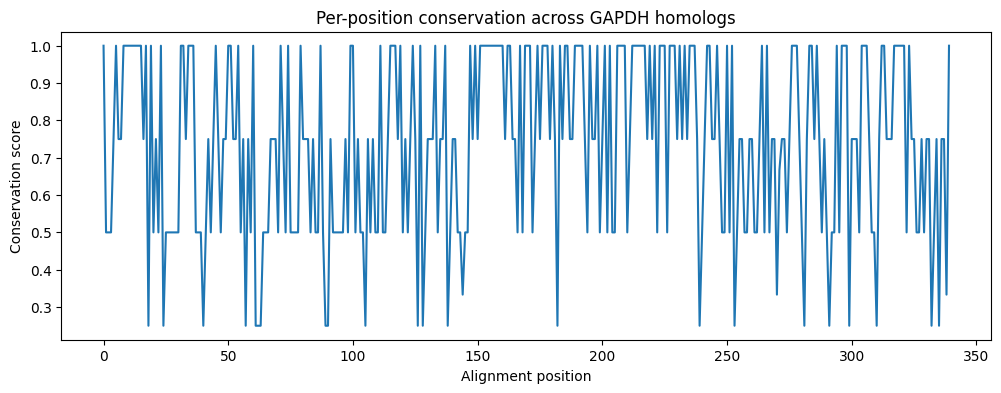

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(conservation_scores.values)
plt.xlabel("Alignment position")
plt.ylabel("Conservation score")
plt.title("Per-position conservation across GAPDH homologs")
plt.show()


### **Per-position conservation analysis revealed a high proportion of strongly conserved residues across GAPDH homologs, consistent with preservation of catalytic and structural regions.**

## **5. Protein Language Model (ESM-2)**

In [ ]:
!pip -q install transformers torch accelerate


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModel

model_name = "facebook/esm2_t6_8M_UR50D"  # small, fast, safe

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

model.eval()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


EsmModel(
  (embeddings): EsmEmbeddings(
    (word_embeddings): Embedding(33, 320, padding_idx=1)
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): EsmEncoder(
    (layer): ModuleList(
      (0-5): 6 x EsmLayer(
        (attention): EsmAttention(
          (self): EsmSelfAttention(
            (query): Linear(in_features=320, out_features=320, bias=True)
            (key): Linear(in_features=320, out_features=320, bias=True)
            (value): Linear(in_features=320, out_features=320, bias=True)
            (rotary_embeddings): RotaryEmbedding()
          )
          (output): EsmSelfOutput(
            (dense): Linear(in_features=320, out_features=320, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (LayerNorm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
        )
        (intermediate): EsmIntermediate(
          (dense): Linear(in_features=320, out_features=1280, bias=True)
        )
        (output): EsmOutput(
        

In [ ]:
type(model)


transformers.models.esm.modeling_esm.EsmModel

## **5.1 Prepare sequences**

In [ ]:
raw_sequences = {
    k: v.replace("-", "")
    for k, v in aligned_sequences.items()
}

{k: len(v) for k, v in raw_sequences.items()}


{'GAPDH_ECOLI_O157': 333,
 'GAPDH_ECOLI_K12': 331,
 'GAPDH_HUMAN': 335,
 'GAPDH_YEAST': 332}

## **5.2 Tokenize sequences**

In [ ]:
inputs = tokenizer(
    list(raw_sequences.values()),
    return_tensors="pt",
    padding=True,
    truncation=True
)

inputs.keys()


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


KeysView({'input_ids': tensor([[ 0, 20,  8,  ...,  2,  1,  1],
        [ 0, 20, 11,  ...,  1,  1,  1],
        [ 0, 20,  6,  ..., 15,  9,  2],
        [ 0, 20,  7,  ...,  1,  1,  1]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0]])})

In [ ]:
inputs.keys()


KeysView({'input_ids': tensor([[ 0, 20,  8,  ...,  2,  1,  1],
        [ 0, 20, 11,  ...,  1,  1,  1],
        [ 0, 20,  6,  ..., 15,  9,  2],
        [ 0, 20,  7,  ...,  1,  1,  1]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0]])})

## **5.3 Embeddings**

In [ ]:
with torch.no_grad():
    outputs = model(**inputs)

outputs.last_hidden_state.shape


torch.Size([4, 337, 320])

## **5.4 Mean-pool embeddings → one vector per protein**

In [ ]:
# Mean pooling using attention mask (ignore padding)
attention_mask = inputs["attention_mask"].unsqueeze(-1)

masked_embeddings = outputs.last_hidden_state * attention_mask
sum_embeddings = masked_embeddings.sum(dim=1)
lengths = attention_mask.sum(dim=1)

protein_embeddings = sum_embeddings / lengths

protein_embeddings.shape


torch.Size([4, 320])

## **5.5 PCA on protein embeddings**

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = protein_embeddings.cpu().numpy()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca.explained_variance_ratio_, pca.explained_variance_ratio_.sum()


(array([0.39354482, 0.34759203], dtype=float32), np.float32(0.74113685))

## **5.6 Visualize embedding space**

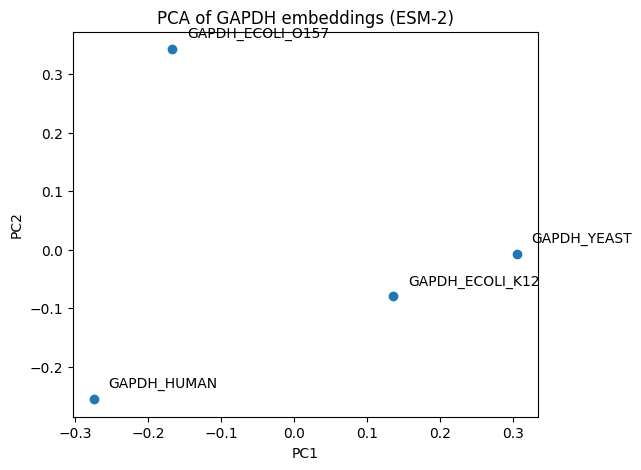

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1])

for i, name in enumerate(raw_sequences.keys()):
    plt.text(X_pca[i,0]+0.02, X_pca[i,1]+0.02, name)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of GAPDH embeddings (ESM-2)")
plt.show()




> **Pretrained ESM-2 protein language model embeddings capture evolutionary structure among GAPDH homologs, with PCA clearly separating bacterial and eukaryotic sequences without task-specific training.**


# **6. PROTEIN SEQUENCE GENERATION (ESM-2)**

**We will generate variants from HUMAN GAPDH**

In [ ]:
base_name = "GAPDH_HUMAN"
base_seq = raw_sequences[base_name]
len(base_seq)


335

## **6.1 Mask a SMALL region**

In [ ]:
# Choose a safe region to mask (middle of sequence)
mask_start = 150
mask_len = 5

masked_seq = (
    base_seq[:mask_start]
    + "<mask>" * mask_len
    + base_seq[mask_start + mask_len:]
)

masked_seq[:170]


'MGKVKVGVNGFGRIGRLVTRAAFNSGKVDIVAINDPFIDLNYMVYMFQYDSTHGKFHGTVKAENGKLVINGNPITIFQERDPSKIKWGDAGAEYVVESTGVFTTMEKAGAHLQGGAKRVIISAPSADAPMFVMGVNHEKYDNSLKIISNA<mask><mask><mask><m'

## **6.2 Use ESM to predict substitutions**

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM

mlm_model_name = "facebook/esm2_t6_8M_UR50D"

mlm_tokenizer = AutoTokenizer.from_pretrained(mlm_model_name)
mlm_model = AutoModelForMaskedLM.from_pretrained(mlm_model_name)

mlm_model.eval()


EsmForMaskedLM(
  (esm): EsmModel(
    (embeddings): EsmEmbeddings(
      (word_embeddings): Embedding(33, 320, padding_idx=1)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): EsmEncoder(
      (layer): ModuleList(
        (0-5): 6 x EsmLayer(
          (attention): EsmAttention(
            (self): EsmSelfAttention(
              (query): Linear(in_features=320, out_features=320, bias=True)
              (key): Linear(in_features=320, out_features=320, bias=True)
              (value): Linear(in_features=320, out_features=320, bias=True)
              (rotary_embeddings): RotaryEmbedding()
            )
            (output): EsmSelfOutput(
              (dense): Linear(in_features=320, out_features=320, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (LayerNorm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
          )
          (intermediate): EsmIntermediate(
            (dense): Linear(in_features=320, out_feat

In [ ]:
type(mlm_model)


transformers.models.esm.modeling_esm.EsmForMaskedLM

In [ ]:
def space_separate(seq):
    return " ".join(list(seq))

mask_start = 150
mask_len = 5

masked_seq = (
    space_separate(base_seq[:mask_start])
    + " " + " ".join(["<mask>"] * mask_len) + " "
    + space_separate(base_seq[mask_start + mask_len:])
)

masked_seq[:300]


'M G K V K V G V N G F G R I G R L V T R A A F N S G K V D I V A I N D P F I D L N Y M V Y M F Q Y D S T H G K F H G T V K A E N G K L V I N G N P I T I F Q E R D P S K I K W G D A G A E Y V V E S T G V F T T M E K A G A H L Q G G A K R V I I S A P S A D A P M F V M G V N H E K Y D N S L K I I S N A '

In [ ]:
from transformers import pipeline

fill_mask = pipeline(
    "fill-mask",
    model=mlm_model,
    tokenizer=mlm_tokenizer,
    top_k=5,
    device=0  # CUDA
)

predictions = fill_mask(masked_seq)
predictions


Device set to use cuda:0


[[{'score': 0.08696616441011429,
   'token': 7,
   'token_str': 'V',
   'sequence': '<cls> M G K V K V G V N G F G R I G R L V T R A A F N S G K V D I V A I N D P F I D L N Y M V Y M F Q Y D S T H G K F H G T V K A E N G K L V I N G N P I T I F Q E R D P S K I K W G D A G A E Y V V E S T G V F T T M E K A G A H L Q G G A K R V I I S A P S A D A P M F V M G V N H E K Y D N S L K I I S N A V <mask> <mask> <mask> <mask> C L A P L A K V I H D N F G I V E G L M T T V H A I T A T Q K T V D G P S G K L W R D G R G A L Q N I I P A S T G A A K A V G K V I P E L N G K L T G M A F R V P T A N V S V V D L T C R L E K P A K Y D D I K K V V K Q A S E G P L K G I L G Y T E H Q V V S S D F N S D T H S S T F D A G A G I A L N D H F V K L I S W Y D N E F G Y S N R V V D L M A H M A S K E <eos>'},
  {'score': 0.0843532457947731,
   'token': 6,
   'token_str': 'G',
   'sequence': '<cls> M G K V K V G V N G F G R I G R L V T R A A F N S G K V D I V A I N D P F I D L N Y M V Y M F Q Y D S T H G K F H G T V 

In [ ]:
# Take top predicted amino acid for each masked position
top_tokens = []

for mask_preds in predictions:
    top_token = mask_preds[0]["token_str"]  # best prediction
    top_tokens.append(top_token)

top_tokens


['V', 'A', 'A', 'A', 'A']

## **6.3 Build the generated variant**

In [ ]:
generated_seq = (
    base_seq[:mask_start]
    + "".join(top_tokens)
    + base_seq[mask_start + mask_len:]
)

len(base_seq), len(generated_seq), generated_seq[145:175]


(335, 335, 'IISNAVAAAACLAPLAKVIHDNFGIVEGLM')

### **Masked-residue prediction generated a conservative local variant of human GAPDH, replacing five residues while preserving global sequence length and surrounding structural context.**

## **6.4 Embedding Distance**

In [ ]:
# Compare embeddings of original vs generated sequence
seqs = [base_seq, generated_seq]
inputs_gen = tokenizer(seqs, return_tensors="pt", padding=True)

# Move input tensors to the same device as the model
inputs_gen = {k: v.to(model.device) for k, v in inputs_gen.items()}

with torch.no_grad():
    out_gen = model(**inputs_gen)

emb = out_gen.last_hidden_state.mean(dim=1)
torch.norm(emb[0] - emb[1])

tensor(0.1541, device='cuda:0')

## **7. Results Summary**

- Strong conservation observed across GAPDH homologs  
- ESM-2 embeddings captured evolutionary structure  
- PCA separated bacterial and eukaryotic proteins  
- Masked-residue prediction generated a conservative variant  


# **8. Conclusion and Future Directions**

This notebook demonstrates that pretrained protein language models can capture evolutionary structure and generate conservative enzyme variants in silico.

**Next steps:**  
- Structural modeling (e.g., AlphaFold) of generated variants  
- Wet-lab validation via expression and activity assays  
- Iterative AI–experiment feedback for protein design
